In [1]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import gc
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import accuracy_score

import utils_ml

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor


In [2]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

old_label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()

In [3]:
# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}



# Example usage:

new_label_arr = utils_ml.convert_labels(old_label_arr, class_to_poles)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

Old Labels:
 [ 0  0  0 ... 34 34 34]
New Labels:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [1 1 2]
 [1 1 2]
 [1 1 2]]


In [4]:
# def extract_feature_list_from_subset(features_arr):

#     data_df = pd.DataFrame()
#     labels_df = pd.Series()

#     subsample_inx = 100
#     subset_features = features_arr[::subsample_inx]
#     data_df['id'] = np.repeat(np.arange(subset_features.shape[0]),subset_features.shape[1])
#     data_df['time'] = np.tile(np.arange(subset_features.shape[1]), subset_features.shape[0])
#     data_df['feature'] = subset_features.flatten()
#     data_df.to_parquet('dataExt/subsample_data_df.parquet')

#     labels_df['labels'] = old_label_arr[::subsample_inx]

    
#     # Load data once
#     dask_df = dd.read_parquet('dataExt/subsample_data_df.parquet', npartitions=10)

#     # Extract features
#     extracted_features = extract_features(dask_df, column_id="id", column_sort="time",n_jobs=-1, disable_progressbar=False).compute()

#     # Handle any NaNs
#     impute(extracted_features)

#     # Convert labels to a Series (ensure it’s 1D if needed)
#     labels_series =  pd.Series(np.array(labels_df.to_numpy()[0]))

#     # Select relevant features
#     features_filtered = select_features(extracted_features, labels_series, multiclass=True)

#     kind_to_fc_parameters = from_columns(features_filtered)

    
#     gc.collect()

#     return kind_to_fc_parameters, features_filtered


# run = False
# if run:
#     all_features = np.concatenate(
#         [np.load(f"{file_prefix}{i:02d}{file_suffix}", allow_pickle=True) for i in range(num_files)],
#         axis=0)
    
#     kind_to_fc_parameters, features_filtered = extract_feature_list_from_subset(all_features)

In [5]:
# Later, load the saved array in memory-mapped mode
features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')
# features_memmap = np.load('dataExt/feat', mmap_mode='r+')


In [6]:
gc.collect()
X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

In [7]:
# # Train the initial model
# xgb_model = XGBRegressor(random_state=42)
# xgb_model.fit(X_train_new, y_train)

# # Get feature importances
# feature_importances = xgb_model.feature_importances_

# # Sort importances and define thresholds
# thresholds = np.sort(feature_importances)[::-1][:200][::10]

# # Define storage for results
# num_features = []
# rmse_means = []
# rmse_stds = []

# # Cross-validation setup
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Loop through thresholds
# for thresh in tqdm(thresholds):
#     # Select features using the current threshold
#     sfm = SelectFromModel(xgb_model, threshold=thresh, prefit=True)
#     X_train_selected = sfm.transform(X_train_new)
    
#     # Skip if no features are selected
#     if X_train_selected.shape[1] == 0:
#         continue
    
#     # Store RMSE values for each fold
#     fold_rmses = []
    
#     for train_idx, val_idx in kf.split(X_train_selected):
#         # Split into training and validation sets
#         X_train_fold, X_val_fold = X_train_selected[train_idx], X_train_selected[val_idx]
#         y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]
        
#         # Train model
#         xgb_model_selected = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
#         xgb_model_selected.fit(X_train_fold, y_train_fold)
        
#         # Predict and calculate RMSE
#         y_val_pred = xgb_model_selected.predict(X_val_fold)
#         fold_rmse = mean_squared_error(y_val_fold, y_val_pred)  # RMSE
#         fold_rmses.append(fold_rmse)
    
#     # Store mean and std of RMSEs across folds
#     num_features.append(X_train_selected.shape[1])
#     rmse_means.append(np.mean(fold_rmses))
#     rmse_stds.append(np.std(fold_rmses))

# # Plot results
# plt.figure(figsize=(8, 5))
# plt.errorbar(num_features, rmse_means, yerr=rmse_stds, fmt='o', capsize=5, label='Mean RMSE ± Std')
# plt.yscale("log")
# plt.xlabel("Number of Selected Features")
# plt.ylabel("RMSE (Lower is Better)")
# plt.title("Number of Selected Features vs. Accuracy (with Cross-Validation)")
# plt.grid()
# plt.legend()
# plt.show()


In [8]:
# # np.float32(0.0009535997)
# xgb_model = XGBRegressor(random_state=42)
# sfm = SelectFromModel(xgb_model, threshold=thresholds[len(thresholds)//2])
# sfm.fit(features_memmap, new_label_arr)
# features_regression_selected = sfm.transform(features_memmap)
# np.save('dataExt/sub_features.npy', features_regression_selected)

In [9]:
# features_regression_selected = np.load('dataExt/sub_features.npy', mmap_mode='r')
# X_train_new, X_test_new, y_train, y_test = train_test_split(features_regression_selected, new_label_arr,random_state=42)
stop

NameError: name 'stop' is not defined

# Option 1: Multiple Submodels

In [ ]:
model_new = MultiOutputRegressor(
  estimator = HistGradientBoostingRegressor(**{'min_samples_leaf': 20, 'max_leaf_nodes': 50, 'max_iter': 300, 'learning_rate': np.float64(0.1), 'l2_regularization': np.float64(0.001),'random_state':42})
)

cv_submodel_sub = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True,verbose=5)

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_sub["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_new)) == y_test,axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy New: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

[CV] END ......................................, score=-0.130 total time= 2.8min
[CV] END ......................................, score=-0.129 total time= 2.7min
[CV] END ......................................, score=-0.129 total time= 2.7min
[CV] END ......................................, score=-0.130 total time= 2.3min
[CV] END ......................................, score=-0.130 total time= 2.6min
Test Accuracy New: 0.6004 ± 0.0012


# Option 2: One model multi output

In [11]:
# # Define the model
# model = XGBRegressor(objective='reg:squarederror', random_state=42)

# # Define the parameter grid with a well-balanced search space
# param_grid = {
#     'learning_rate': np.logspace(-3, 0, 10),      # Learning rates between 0.001 and 1
#     'n_estimators': [50, 100, 200, 300],          # Number of boosting rounds
#     'max_depth': [3, 5, 7, 10],                   # Maximum depth of trees
#     'min_child_weight': [1, 3, 5, 10],            # Minimum sum of weights of all children
#     'subsample': [0.6, 0.8, 1.0],                 # Subsample ratio of training instances
#     'colsample_bytree': [0.6, 0.8, 1.0],          # Subsample ratio of features per tree
#     'reg_alpha': np.logspace(-3, 1, 5),           # L1 regularization strength
#     'reg_lambda': np.logspace(-3, 1, 5)           # L2 regularization strength
# }

# # Define the Halving Random Search with cross-validation
# halving_search = HalvingRandomSearchCV(
#     estimator=model,
#     param_distributions=param_grid,
#     factor=2,                        # Halving factor: reduce candidate configurations by half
#     cv=5,                            # 5-fold cross-validation
#     scoring='neg_mean_squared_error', # Use RMSE as evaluation metric (negative since higher scores are better)
#     random_state=42,
#     n_jobs=-1,                       # Use all available CPU cores
#     verbose=1                        # Increase verbosity for better monitoring
# )

# # Perform the halving search
# halving_search.fit(X_train_new, y_train)

# # Print the best parameters and score
# print("Best parameters found: ", halving_search.best_params_)
# print("Best cross-validation accuracy: {:.2f}".format(halving_search.best_score_))

# # Evaluate the best model on the test set
# best_model = halving_search.best_estimator_

In [19]:
X_train_new

array([[ 1.37088410e+09,  2.56336397e-01,  2.28147232e-01, ...,
         3.72674077e+06,  9.14881010e+02,  6.42290317e-02],
       [ 1.37084570e+09,  2.56459098e-01,  2.28021341e-01, ...,
         9.94005991e+06,  1.20339759e+04,  2.06991346e-01],
       [ 1.37082972e+09,  2.56581467e-01,  2.27701454e-01, ...,
         5.84074603e+06,  2.75530470e+03,  1.07192332e-01],
       ...,
       [ 1.37081184e+09,  2.56259603e-01,  2.29309204e-01, ...,
         1.48410565e+06,  2.01178852e+03,  7.77261285e-02],
       [ 1.37087314e+09,  2.56499073e-01,  2.28497775e-01, ...,
        -5.11295143e+05,  3.50091070e+03,  9.71279378e-02],
       [ 1.37076834e+09,  2.56376474e-01,  2.27994962e-01, ...,
         5.83522701e+06,  4.70533441e+03,  1.25228239e-01]])

In [24]:
# model_new = XGBRegressor(**{'subsample': 0.6, 'reg_lambda': np.float64(0.1), 'reg_alpha': np.float64(1.0), 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': np.float64(0.046415888336127774), 'colsample_bytree': 0.6})
model_new = XGBRegressor(objective='reg:squarederror', random_state=42)
cv_submodel_new = cross_validate(model_new, X_train_new, y_train, cv=2, scoring='neg_mean_squared_error', return_estimator=True, verbose=5)

res_arr = np.zeros(2)
for cnt,est in enumerate(cv_submodel_new["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_new)) == y_test,axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy New: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

[CV] END ......................................, score=-0.140 total time= 1.5min
[CV] END ......................................, score=-0.141 total time= 1.5min
Test Accuracy New: 0.5755 ± 0.0023


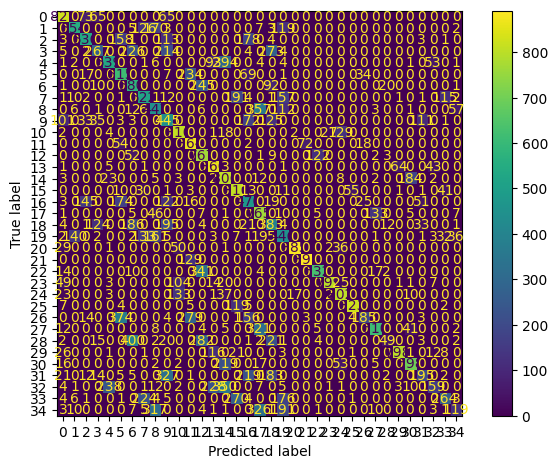

In [25]:
predictions = utils_ml.reconvert_labels(np.abs(np.round(cv_submodel_new["estimator"][0].predict(X_test_new),0)).tolist(),class_to_poles)
cm = confusion_matrix(utils_ml.reconvert_labels(y_test,class_to_poles), predictions, labels=np.arange(35))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.arange(35))
disp.plot()
plt.tight_layout()
plt.show()

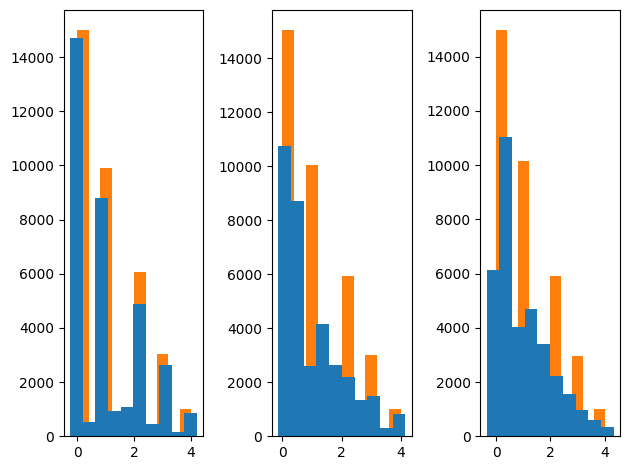

In [ ]:
fig, axs = plt.subplots(1,3)

axs[0].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,0])
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,1])
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,2])
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

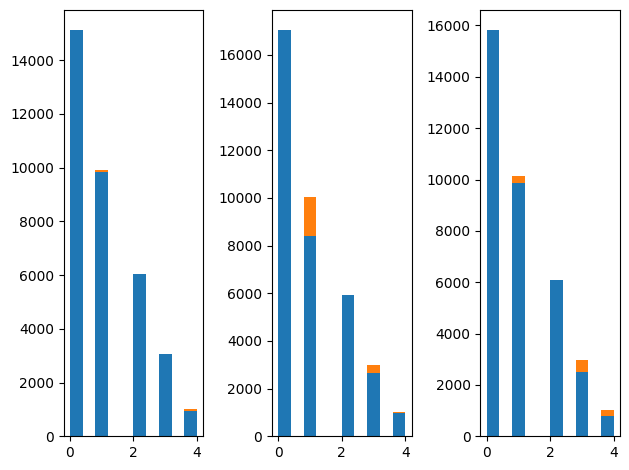

In [ ]:
fig, axs = plt.subplots(1,3)

axs[0].hist(np.round(cv_submodel_new['estimator'][0].predict(X_test_new)[:,0]))
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist(np.round(cv_submodel_new['estimator'][0].predict(X_test_new)[:,1]))
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist(np.round(cv_submodel_new['estimator'][0].predict(X_test_new)[:,2]))
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

In [1]:
# class PoleDataset(Dataset):
#     def __init__(self, features, targets):
#         self.features = torch.tensor(features, dtype=torch.float32)
#         self.targets = torch.tensor(targets, dtype=torch.float32)
        
#     def __len__(self):
#         return len(self.features)
    
#     def __getitem__(self, idx):
#         return self.features[idx], self.targets[idx]


# scaler = StandardScaler()
# features_memmap_scaled = scaler.fit_transform(features_memmap)
# X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap_scaled, new_label_arr)

# # scaler = StandardScaler()
# # features_all_scaled = scaler.fit_transform(features_memmap)
# # X_train_old, X_test_old, _, _ = train_test_split(features_all_scaled, new_label_arr)


# # Create Dataset objects
# train_dataset = PoleDataset(X_train_new, y_train)
# test_dataset = PoleDataset(X_test_new, y_test)

# # Create DataLoaders
# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [2]:
# # Define the neural network model
# class PoleRegression(nn.Module):
#     def __init__(self, input_size=521, hidden_size=100):
#         super(PoleRegression, self).__init__()
#         # Define layers
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
#         self.output = nn.Linear(hidden_size, 3)  # Output size of 3 for regression targets

#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         return self.output(x)

# # Initialize model, loss function, and optimizer
# model = PoleRegression()
# criterion = nn.MSELoss()  # MSE Loss for regression
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

# num_epochs = 1000
# train_losses = []
# test_losses = []

# patience = 10  # Number of epochs to wait for improvement
# min_delta = 1e-4  # Minimum change to qualify as an improvement
# best_test_loss = float('inf')  # Initialize best test loss as infinity
# patience_counter = 0  # Counter to track epochs without improvement

# # Training loop with early stopping
# for epoch in range(num_epochs):
#     # Train phase
#     model.train()
#     train_loss = 0.0
#     for inputs, targets in train_loader:
#         optimizer.zero_grad()  # Reset gradients
#         outputs = model(inputs)  # Get model predictions
#         loss = criterion(outputs, targets)  # Calculate MSE loss
#         loss.backward()  # Backpropagate the loss
#         optimizer.step()  # Update the model weights
        
#         train_loss += loss.item()  # Accumulate loss for tracking
    
#     # Average training loss for this epoch
#     train_loss /= len(train_loader)
#     train_losses.append(train_loss)
    
#     # Test phase (evaluate model on validation/test data)
#     model.eval()
#     test_loss = 0.0
#     with torch.no_grad():  # No need to track gradients for evaluation
#         for inputs, targets in test_loader:
#             outputs = model(inputs)  # Get model predictions
#             loss = criterion(outputs, targets)  # Calculate MSE loss
#             test_loss += loss.item()  # Accumulate loss for tracking
    
#     # Average test loss for this epoch
#     test_loss /= len(test_loader)
#     test_losses.append(test_loss)
    
#     # Print epoch stats every 10 epochs
#     if epoch % 10 == 0:
#         print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
#     # Early stopping check
#     if test_loss < best_test_loss - min_delta:
#         best_test_loss = test_loss
#         patience_counter = 0  # Reset counter if test loss improves
#     else:
#         patience_counter += 1  # Increment counter if no improvement
    
#     if patience_counter >= patience:
#         print(f"Early stopping at epoch {epoch+1} with best test loss: {best_test_loss:.4f}")
#         break


In [3]:
# # Plot train and test loss
# plt.figure(figsize=(10, 6))
# plt.plot(range(1, epoch +2), train_losses, label='Train Loss', color='blue')
# plt.plot(range(1, epoch +2), test_losses, label='Test Loss', color='red')
# plt.xlabel('Epochs')
# plt.ylabel('Loss')
# plt.title('Training and Test Loss over Epochs')
# plt.legend()
# plt.grid(True)

# # plt.yscale("log")
# # plt.ylim(0,0.5)
# plt.show()

In [4]:
# model.eval()

# acc_arr = []
# with torch.no_grad():  # No need to track gradients for evaluation
#     for inputs, targets in test_loader:
#         outputs = model(inputs)  # Get model predictions
#         acc_arr.append(torch.sum(torch.sum(np.round(outputs) == targets,axis=1) == 3)/targets.shape[0])
# np.mean(acc_arr)

In [ ]:
# class PoleClassifier(nn.Module):
#     def __init__(self, input_size=100, hidden_size=100):
#         super(PoleClassifier, self).__init__()
#         # Define layers
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
        
#         # Outputs for binary presence of poles on each position
#         self.presence_bt = nn.Linear(hidden_size, 1)  # Binary presence for [bt]
#         self.presence_bb = nn.Linear(hidden_size, 1)  # Binary presence for [bb]
#         self.presence_tb = nn.Linear(hidden_size, 1)  # Binary presence for [tb]
        
#         # Outputs for count of poles at each position
#         self.count_bt = nn.Linear(hidden_size, 1)     # Count of poles on [bt]
#         self.count_bb = nn.Linear(hidden_size, 1)     # Count of poles on [bb]
#         self.count_tb = nn.Linear(hidden_size, 1)     # Count of poles on [tb]
        
#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
        
#         # Presence predictions (binary)
#         presence_bt = torch.sigmoid(self.presence_bt(x))
#         presence_bb = torch.sigmoid(self.presence_bb(x))
#         presence_tb = torch.sigmoid(self.presence_tb(x))
        
#         # Count predictions (continuous)
#         count_bt = F.relu(self.count_bt(x))
#         count_bb = F.relu(self.count_bb(x))
#         count_tb = F.relu(self.count_tb(x))
        
#         return torch.concatenate([presence_bt,
#                 presence_bb,
#                 presence_tb,
#                 count_bt,
#                 count_bb,
#                 count_tb],dim=1)


# # Custom loss function combining binary cross-entropy (for presence) and MSE (for counts)
# class CustomLoss(nn.Module):
#     def __init__(self):
#         super(CustomLoss, self).__init__()
    
#     def forward(self, outputs, targets):

#         # Split outputs and targets into presence and count parts
#         pred_presence = outputs[:, :3]  # Presence predictions (bt, bb, tb)
#         pred_counts = outputs[:, 3:]    # Count predictions (bt, bb, tb)

#         target_presence = targets[:, :3]  # Presence targets
#         target_counts = targets[:, 3:]    # Count targets

#         # Binary Cross-Entropy for presence
#         presence_loss = nn.BCEWithLogitsLoss()(pred_presence, target_presence)
        
#         # Mean Squared Error for counts
#         count_loss = nn.MSELoss()(pred_counts, target_counts)

#         # Total loss (combining both)
#         total_loss = presence_loss + count_loss
#         return total_loss

In [5]:
# fig,axs = plt.subplots(1,2,figsize=(5,5))

# axs[0].imshow(targets)
# axs[1].imshow(np.round(outputs.numpy() ))

# fig.tight_layout()

In [6]:
# import torch

# def get_class_from_output(outputs):
#     # Round the outputs
#     presence_bt, presence_bb, presence_tb = np.round(outputs[0].numpy()), np.round(outputs[1].numpy()), np.round(outputs[2].numpy())
#     count_bt, count_bb, count_tb = np.round(outputs[3].numpy()), np.round(outputs[4].numpy()), np.round(outputs[5].numpy())

#     # Map the rounded output to a class (0-7)
#     class_mapping = {
#         (1, 0, 0, 0, 0, 0): 0,  # Presence: bt, count: bt = 0
#         (0, 1, 0, 0, 0, 0): 1,  # Presence: bb, count: bb = 0
#         (0, 0, 1, 0, 0, 0): 2,  # Presence: tb, count: tb = 0
#         (1, 1, 0, 1, 0, 0): 3,  # Presence: bt + bb, count: bt = 1
#         (1, 0, 1, 0, 1, 0): 4,  # Presence: bt + tb, count: bb = 1
#         (0, 1, 1, 0, 1, 0): 5,  # Presence: bb + tb, count: bb = 1
#         (1, 1, 1, 1, 1, 0): 6,  # Presence: bt + bb + tb, count: bt = 1
#         (1, 0, 0, 2, 0, 0): 7   # Presence: bt, count: bt = 2
#     }
    
#     # Map the rounded values to the class label
#     class_label = class_mapping.get((presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb), -1)

#     print(presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb, class_label)
#     return class_label

# def convert_to_class_matrix(outputs):
#     """
#     Given the outputs for a batch of samples, convert them to the class matrix
#     where each row corresponds to the class of a sample.
#     """
#     class_labels = []

#     for output in outputs:
#         class_label = get_class_from_output(output)
#         class_labels.append(class_label)
    
#     return torch.tensor(class_labels)



# class_matrix = convert_to_class_matrix(outputs)
# print(class_matrix)  # This will give the class labels for each sample in the batch.


In [7]:
# def get_class_from_output(outputs):
#     # Convert outputs into a tuple of presence and count
#     presence_bt, presence_bb, presence_tb = outputs[:,0], outputs[:,1], outputs[:,2]
#     count_bt, count_bb, count_tb = outputs[:,3], outputs[:,4], outputs[:,5]
    
#     # Convert continuous count values into discrete values (e.g., rounding)
#     count_bt = np.round(count_bt.numpy())
#     count_bb = np.round(count_bb.numpy())
#     count_tb = np.round(count_tb.numpy())
    
#     # Convert presence to binary (0 or 1)
#     presence_bt = np.round(presence_bt.numpy())
#     presence_bb = np.round(presence_bb.numpy())
#     presence_tb = np.round(presence_tb.numpy())
    
#     # Create a tuple of (presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb)
#     # We map this tuple into a class index
#     class_mapping = {
#         (1, 0, 0, 1, 0, 0): 0,  # Class 0
#         (0, 1, 0, 0, 1, 0): 1,  # Class 1
#         (0, 0, 1, 0, 0, 1): 2,  # Class 2
#         (1, 1, 0, 1, 1, 0): 3,  # Class 3
#         (0, 1, 1, 0, 1, 1): 4,  # Class 4
#         (1, 1, 1, 1, 1, 1): 5,  # Class 5
#         (0, 2, 0, 0, 2, 0): 6,  # Class 6
#         (0, 1, 2, 0, 1, 2): 7   # Class 7
#     }
    
#     return class_mapping.get((presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb), -1)  # -1 if no match
# get_class_from_output(outputs)